## **Лабораторная работа №2**

Реализовать с помощью `Numpy` класс `MyMLP`, моделирующий работу полносвязной нейронной сети.

Реализуемый класс должен

1. Поддерживать создание любого числа слоев с любым числом нейронов. Тип инициализации весов не регламентируется.
2. Обеспечивать выбор следующих функции активации в рамках каждого слоя: `ReLU`, `sigmoid`, `linear`.
3. Поддерживать решение задачи классификации и регрессии (выбор соответствующего лосса, в том числе для задачи многоклассовой классификации).
4. В процессе обучения использовать самостоятельно реализованный механизм обратного распространения (вывод формул в формате markdown) для применения градиентного и стохастического градиентного спусков (с выбором размера батча)
5. Поддерживать использование `l1`, `l2` и `l1l2` регуляризаций.

Самостоятельно выбрать наборы данных (классификация и регрессия). Провести эксперименты (различные конфигурации сети: количество слоев, нейронов, функции активации, скорость обучения и тп. — минимум 5 различных конфигураций) и сравнить результаты работы (оценка качества модели + время обучения и инференса) реализованного класса `MyMLP` со следующими моделям (в одинаковых конфигурациях):

*   MLPClassifier/MLPRegressor из sklearn
*   TensorFlow
*   Keras
*   PyTorch

Результат представить в виде .ipynb блокнота, содержащего весь необходимый код и визуализации сравнения реализаций для рассмотренных конфигураций.


**Функции потерь**

1.MSE (регрессия)

$\mathcal{L} = \frac{1}{m} \sum_{i=1}^{m} (y_i - \hat{y}_i)^2$

2.Binary Cross-Entropy

$\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \left[ y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i) \right]$

3.Categorical Cross-Entropy

$\mathcal{L} = -\frac{1}{m} \sum_{i=1}^{m} \sum_{k=1}^{K} y_{ik} \log(\hat{y}_{ik})$

**Функции активации и их производные**

1.ReLU:

$
f(z) = \max(0, z) \\
f'(z) = \begin{cases}
1, & \text{если } z > 0 \\
0, & \text{если } z \leq 0
\end{cases}
$

2.Sigmoid:

$ f(z) = \frac{1}{1 + e^{-z}} $

$ f'(z) = f(z)(1 - f(z)) $

3.Softmax:
$
f(z_i) = \frac{e^{z_i}}{\sum_{j} e^{z_j}} \\
\frac{\partial f(z_i)}{\partial z_j} = \begin{cases}
f(z_i)(1 - f(z_i)), & \text{если } i = j \\
-f(z_i)f(z_j), & \text{если } i \neq j
\end{cases}
$

4.Linear

$f(z) = z$

$f'(z) = 1$

**Регуляризация**

1.L1-регуляризация:

$
\frac{\partial R}{\partial W} = \lambda \cdot \text{sign}(W)
$

2.L2-регуляризация:

$
\frac{\partial R}{\partial W} = 2\lambda W
$

3.L1L2-регуляризация:

$
\frac{\partial R}{\partial W} = \lambda_1 \cdot \text{sign}(W) + 2\lambda_2 W
$

In [ ]:
!pip install torch tensorflow scikit-learn

In [11]:
# Импортируем необходимы для работы библиотеки
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.neural_network import MLPClassifier
from sklearn.neural_network import MLPRegressor
import kagglehub
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [22]:
# Зафиксируем seed
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)
    torch.manual_seed(seed)

In [3]:
class MyMLP:
    def __init__(
        self,
        layer_sizes,
        activations,
        loss="mse",
        learning_rate=0.01,
        reg_type=None,
        reg_lambda=0.0,
        seed=42):

        assert len(layer_sizes) >= 2
        assert len(activations) == len(layer_sizes) - 1

        supported_activations = {"relu", "sigmoid", "linear", "softmax"}

        for act in activations:
            assert act in supported_activations

        supported_losses = {"mse", "binary_crossentropy", "categorical_crossentropy"}
        assert loss in supported_losses

        if "softmax" in activations[:-1]:
            raise ValueError("Softmax разрешён только на выходном слое")

        if loss == "categorical_crossentropy" and activations[-1] != "softmax":
            raise ValueError("Для categorical_crossentropy нужен softmax на выходе")

        if loss == "binary_crossentropy" and activations[-1] != "sigmoid":
            raise ValueError("Для binary_crossentropy нужен sigmoid на выходе")

        np.random.seed(seed)

        self.layer_sizes = layer_sizes
        self.activations = activations
        self.loss_name = loss
        self.lr = learning_rate
        self.reg_type = reg_type
        self.reg_lambda = reg_lambda

        self.weights = []
        self.biases = []

        self._Zs = []
        self._As = []

        self._init_weights()

    def _init_weights(self):
        for i in range(len(self.layer_sizes) - 1):
            in_dim = self.layer_sizes[i]
            out_dim = self.layer_sizes[i + 1]

            if self.activations[i] == "relu":
                W = np.random.randn(in_dim, out_dim) * np.sqrt(2.0 / in_dim)
            else:
                W = np.random.randn(in_dim, out_dim) * np.sqrt(1.0 / in_dim)

            b = np.zeros((1, out_dim))

            self.weights.append(W)
            self.biases.append(b)

    def _activation(self, Z, func):
        if func == "relu":
            return np.maximum(0, Z)

        elif func == "sigmoid":
            Z = np.clip(Z, -500, 500)
            return 1 / (1 + np.exp(-Z))

        elif func == "linear":
            return Z

        elif func == "softmax":
            Z = Z - np.max(Z, axis=1, keepdims=True)
            expZ = np.exp(Z)
            return expZ / (np.sum(expZ, axis=1, keepdims=True) + 1e-8)

    def _activation_derivative(self, Z, func):
        if func == "relu":
            return (Z > 0).astype(float)

        elif func == "sigmoid":
            Z = np.clip(Z, -500, 500)
            s = 1 / (1 + np.exp(-Z))
            return s * (1 - s)

        elif func == "linear":
            return np.ones_like(Z)

        raise ValueError("Derivative not defined")


    def _forward(self, X, cache=True):
        A = X

        if cache:
            self._Zs = []
            self._As = [X]

        for W, b, act in zip(self.weights, self.biases, self.activations):
            Z = A @ W + b
            A = self._activation(Z, act)

            if cache:
                self._Zs.append(Z)
                self._As.append(A)

        return A

    def _compute_loss(self, y, y_pred):
        m = y.shape[0]

        if self.loss_name == "mse":
            loss = np.mean((y - y_pred) ** 2)

        elif self.loss_name == "binary_crossentropy":
            loss = -np.mean(
                y * np.log(y_pred + 1e-8) +
                (1 - y) * np.log(1 - y_pred + 1e-8))

        elif self.loss_name == "categorical_crossentropy":
            loss = -np.mean(np.sum(y * np.log(y_pred + 1e-8), axis=1))

        # Регуляризация
        if self.reg_type and self.reg_lambda > 0:
            reg = 0
            for W in self.weights:
                if self.reg_type == "l2":
                    reg += np.sum(W ** 2)
                elif self.reg_type == "l1":
                    reg += np.sum(np.abs(W))
                elif self.reg_type == "l1l2":
                    reg += np.sum(W ** 2) + np.sum(np.abs(W))

            loss += self.reg_lambda * reg / m

        return loss

    def _backward(self, y, y_pred):
        m = y.shape[0]
        L = len(self.weights)

        dA = None

        for i in reversed(range(L)):
            W = self.weights[i]
            Z = self._Zs[i]
            A_prev = self._As[i]
            act = self.activations[i]

            # Выходной слой
            if i == L - 1:
                if self.loss_name == "mse":
                    dZ = (2 / m) * (y_pred - y) * self._activation_derivative(Z, act)

                elif self.loss_name == "binary_crossentropy":
                    dZ = (y_pred - y) / m

                elif self.loss_name == "categorical_crossentropy":
                    dZ = (y_pred - y) / m

            else:
                dZ = dA * self._activation_derivative(Z, act)

            dW = A_prev.T @ dZ
            db = np.sum(dZ, axis=0, keepdims=True)

            # Регуляризация
            if self.reg_type and self.reg_lambda > 0:
                if self.reg_type == "l2":
                    dW += 2 * self.reg_lambda * W / m
                elif self.reg_type == "l1":
                    dW += self.reg_lambda * np.sign(W) / m
                elif self.reg_type == "l1l2":
                    dW += self.reg_lambda * (2 * W + np.sign(W)) / m

            if i > 0:
                dA = dZ @ W.T

            self.weights[i] -= self.lr * dW
            self.biases[i] -= self.lr * db

    def fit(self, X, y, epochs=100, batch_size=None, verbose=True):
        n = X.shape[0]

        # Проверка размерностей
        assert X.shape[1] == self.layer_sizes[0]

        self.loss_history = []

        for epoch in range(epochs):
            idx = np.random.permutation(n)
            X_shuffled = X[idx]
            y_shuffled = y[idx]

            # Разбивка на батчи
            if batch_size is None:
                batches = [(X_shuffled, y_shuffled)]
            else:
                batches = [(X_shuffled[i:i + batch_size], y_shuffled[i:i + batch_size])
                for i in range(0, n, batch_size)]

            epoch_loss = 0

            for Xb, yb in batches:
                y_pred = self._forward(Xb)
                # Loss (логирование)
                loss = self._compute_loss(yb, y_pred)
                epoch_loss += loss

                # Backward
                self._backward(yb, y_pred)

            # Средний loss за эпоху
            epoch_loss /= len(batches)
            self.loss_history.append(epoch_loss)

            if verbose:
                print(f"Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss:.6f}")

    def predict(self, X):
        return self._forward(X, cache=False)

    def predict_classes(self, X):
        y = self.predict(X)

        if y.shape[1] == 1:
            return (y.ravel() > 0.5).astype(int)

        return np.argmax(y, axis=1)

### **Классификация**

Для решения задачи классификации будет использоваться датасет [Adult Census Income](https://www.kaggle.com/datasets/uciml/adult-census-income) с Kaggle, содержащий информацию о взрослом населении для прогнозирования доходов.

In [4]:
# Импортируем датасет
path = kagglehub.dataset_download("uciml/adult-census-income")
print("Dataset path:", path)

df_classification = pd.read_csv(path + "/adult.csv")
df_classification.head()

Using Colab cache for faster access to the 'adult-census-income' dataset.
Dataset path: /kaggle/input/adult-census-income


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [5]:
# Удаляем пропуски
df_classification = df_classification.replace("?", np.nan).dropna()

In [6]:
# Разделяем датасет
X = df_classification.drop("income", axis=1)
y = df_classification["income"]

y = (y == ">50K").astype(int).values

In [7]:
X = pd.get_dummies(X)

# Делим данные на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Масштабируем
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# Конфигурации
configs = [
    {"layers": [32], "acts": ["relu"], "lr": 0.01},
    {"layers": [64, 32], "acts": ["relu", "relu"], "lr": 0.01},
    {"layers": [64, 32], "acts": ["relu", "sigmoid"], "lr": 0.01},
    {"layers": [64, 32], "acts": ["relu", "relu"], "lr": 0.001},
    {"layers": [64, 32], "acts": ["relu", "relu"], "lr": 0.01, "reg": "l2", "lambda": 0.01},
    {"layers": [128, 64, 32], "acts": ["relu", "relu", "relu"], "lr": 0.01},]

In [23]:
results = []

for i, cfg in enumerate(configs):
    set_seed(42)
    layers = cfg["layers"]
    acts = cfg["acts"]
    lr = cfg["lr"]
    reg_type = cfg.get("reg")
    reg_lambda = cfg.get("lambda", 0.0)

    print(f"\nКонфигурация {i+1}")
    print(f"Слои: {layers}")
    print(f"Активации: {acts}")
    print(f"Learning rate: {lr}")
    print(f"Регуляризация: {reg_type}, lambda={reg_lambda}")

    # Проверка
    assert len(layers) == len(acts)

    # Архитектура
    layer_sizes = [X_train.shape[1]] + layers + [1]
    activations = acts + ["sigmoid"]

    # Модель
    model = MyMLP(
        layer_sizes=layer_sizes,
        activations=activations,
        loss="binary_crossentropy",
        learning_rate=lr,
        reg_type=reg_type,
        reg_lambda=reg_lambda)

    # Обучение
    start = time.time()
    model.fit(
        X_train,
        y_train.reshape(-1, 1),
        epochs=50,
        batch_size=64,
        verbose=False)

    train_time = time.time() - start
    final_loss = model.loss_history[-1]

    # Инференс
    start = time.time()
    y_pred = model.predict(X_test)
    infer_time = time.time() - start

    y_pred_class = (y_pred > 0.5).astype(int)

    # Метрики
    acc = accuracy_score(y_test, y_pred_class)
    f1 = f1_score(y_test, y_pred_class)

    results.append({
        "model": "MyMLP",
        "config": i + 1,
        "accuracy": acc,
        "f1": f1,
        "loss": final_loss,
        "train_time": train_time,
        "infer_time": infer_time})

    print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}")


Конфигурация 1
Слои: [32]
Активации: ['relu']
Learning rate: 0.01
Регуляризация: None, lambda=0.0
Accuracy: 0.8460, F1: 0.6686

Конфигурация 2
Слои: [64, 32]
Активации: ['relu', 'relu']
Learning rate: 0.01
Регуляризация: None, lambda=0.0
Accuracy: 0.8405, F1: 0.6554

Конфигурация 3
Слои: [64, 32]
Активации: ['relu', 'sigmoid']
Learning rate: 0.01
Регуляризация: None, lambda=0.0
Accuracy: 0.8394, F1: 0.6498

Конфигурация 4
Слои: [64, 32]
Активации: ['relu', 'relu']
Learning rate: 0.001
Регуляризация: None, lambda=0.0
Accuracy: 0.8256, F1: 0.6115

Конфигурация 5
Слои: [64, 32]
Активации: ['relu', 'relu']
Learning rate: 0.01
Регуляризация: l2, lambda=0.01
Accuracy: 0.8410, F1: 0.6559

Конфигурация 6
Слои: [128, 64, 32]
Активации: ['relu', 'relu', 'relu']
Learning rate: 0.01
Регуляризация: None, lambda=0.0
Accuracy: 0.8392, F1: 0.6402


In [24]:
# Sklearn
for i, cfg in enumerate(configs):
    set_seed(42)
    layers = tuple(cfg["layers"])
    lr = cfg["lr"]

    print(f"\n[sklearn] Конфигурация {i+1}")

    model = MLPClassifier(
        hidden_layer_sizes=layers,
        activation='relu',
        learning_rate_init=lr,
        max_iter=50,
        batch_size=64,
        random_state=42)

    # Обучение
    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    # Инференс
    start = time.time()
    y_pred = model.predict(X_test)
    infer_time = time.time() - start

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "model": "sklearn",
        "config": i + 1,
        "accuracy": acc,
        "f1": f1,
        "train_time": train_time,
        "infer_time": infer_time})

    print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}")


[sklearn] Конфигурация 1


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.8420, F1: 0.6561

[sklearn] Конфигурация 2


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.8364, F1: 0.6226

[sklearn] Конфигурация 3


...

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.8324, F1: 0.6419

[sklearn] Конфигурация 5


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


Accuracy: 0.8364, F1: 0.6226

[sklearn] Конфигурация 6
Accuracy: 0.8331, F1: 0.6495


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (50) reached and the optimization hasn't converged yet.
  warnings.warn(


In [25]:
# TensorFlow
for i, cfg in enumerate(configs):
    set_seed(42)

    print(f"\n[TensorFlow] Конфигурация {i+1}")

    weights_tf = []
    biases_tf = []
    prev_dim = X_train.shape[1]

    for units in cfg["layers"]:
        W = tf.Variable(tf.random.normal([prev_dim, units], stddev=0.1))
        b = tf.Variable(tf.zeros([units]))
        weights_tf.append(W)
        biases_tf.append(b)
        prev_dim = units

    W_out = tf.Variable(tf.random.normal([prev_dim, 1], stddev=0.1))
    b_out = tf.Variable(tf.zeros([1]))

    optimizer = tf.optimizers.Adam(learning_rate=cfg["lr"])

    X_tf = tf.constant(X_train, dtype=tf.float32)
    y_tf = tf.constant(y_train.reshape(-1, 1), dtype=tf.float32)

    dataset = tf.data.Dataset.from_tensor_slices((X_tf, y_tf))
    dataset = dataset.shuffle(buffer_size=1000).batch(64)

    def forward(X):
        A = X
        for W, b, act in zip(weights_tf, biases_tf, cfg["acts"]):
            Z = A @ W + b
            if act == "relu":
                A = tf.nn.relu(Z)
            elif act == "sigmoid":
                A = tf.nn.sigmoid(Z)
            else:
                A = Z
        return tf.nn.sigmoid(A @ W_out + b_out)

    @tf.function
    def train_step(Xb, yb):
        with tf.GradientTape() as tape:
            y_pred = forward(Xb)
            loss = tf.reduce_mean(
                tf.keras.losses.binary_crossentropy(yb, y_pred))
        all_vars = weights_tf + biases_tf + [W_out, b_out]
        grads = tape.gradient(loss, all_vars)
        optimizer.apply_gradients(zip(grads, all_vars))

    # Обучение
    start = time.time()
    for epoch in range(50):
        for Xb, yb in dataset:
            train_step(Xb, yb)
    train_time = time.time() - start

    # Инференс
    X_test_tf = tf.constant(X_test, dtype=tf.float32)
    start = time.time()
    y_pred = (forward(X_test_tf).numpy() > 0.5).astype(int)
    infer_time = time.time() - start

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "model": "tensorflow",
        "config": i + 1,
        "accuracy": acc,
        "f1": f1,
        "train_time": train_time,
        "infer_time": infer_time})

    print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}")


[TensorFlow] Конфигурация 1
Accuracy: 0.8386, F1: 0.6544

[TensorFlow] Конфигурация 2
Accuracy: 0.8356, F1: 0.6222

[TensorFlow] Конфигурация 3
Accuracy: 0.8452, F1: 0.6652

[TensorFlow] Конфигурация 4
Accuracy: 0.8364, F1: 0.6519

[TensorFlow] Конфигурация 5
Accuracy: 0.8356, F1: 0.6222

[TensorFlow] Конфигурация 6
Accuracy: 0.8359, F1: 0.6514


In [26]:
# Keras
for i, cfg in enumerate(configs):
    set_seed(42)

    print(f"\n[Keras] Конфигурация {i+1}")

    model = Sequential()

    # Первый слой
    model.add(Dense(cfg["layers"][0], activation=cfg["acts"][0], input_shape=(X_train.shape[1],)))

    # Скрытые слои
    for units, act in zip(cfg["layers"][1:], cfg["acts"][1:]):
        model.add(Dense(units, activation=act))

    # Выход
    model.add(Dense(1, activation="sigmoid"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg["lr"]),
        loss="binary_crossentropy",
        metrics=["accuracy"])

    # Обучение
    start = time.time()
    model.fit(
        X_train, y_train,
        epochs=50,
        batch_size=64,
        verbose=0)

    train_time = time.time() - start

    # Инференс
    start = time.time()
    y_pred = (model.predict(X_test) > 0.5).astype(int)
    infer_time = time.time() - start

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "model": "keras",
        "config": i + 1,
        "accuracy": acc,
        "f1": f1,
        "train_time": train_time,
        "infer_time": infer_time})

    print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}")


[Keras] Конфигурация 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.8362, F1: 0.6786

[Keras] Конфигурация 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.8333, F1: 0.6195

[Keras] Конфигурация 3


...

189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy: 0.8228, F1: 0.6660

[Keras] Конфигурация 5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.8333, F1: 0.6195

[Keras] Конфигурация 6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy: 0.8329, F1: 0.6608


In [27]:
# PyTorch
class TorchMLP(nn.Module):
    def __init__(self, input_dim, layers, acts):
        super().__init__()

        modules = []
        prev_dim = input_dim

        act_map = {
            "relu": nn.ReLU(),
            "sigmoid": nn.Sigmoid()}

        for units, act in zip(layers, acts):
            modules.append(nn.Linear(prev_dim, units))
            modules.append(act_map[act])
            prev_dim = units

        modules.append(nn.Linear(prev_dim, 1))
        modules.append(nn.Sigmoid())

        self.net = nn.Sequential(*modules)

    def forward(self, x):
        return self.net(x)

for i, cfg in enumerate(configs):
    set_seed(42)

    print(f"\n[PyTorch] Конфигурация {i+1}")

    model = TorchMLP(X_train.shape[1], cfg["layers"], cfg["acts"])
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=cfg["lr"])

    X_t = torch.tensor(X_train, dtype=torch.float32)
    y_t = torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)

    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    # Обучение
    start = time.time()
    for epoch in range(50):
        for Xb, yb in loader:
            optimizer.zero_grad()
            outputs = model(Xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
    train_time = time.time() - start

    # Инференс
    X_test_t = torch.tensor(X_test, dtype=torch.float32)

    start = time.time()
    with torch.no_grad():
        y_pred = (model(X_test_t).numpy() > 0.5).astype(int)
    infer_time = time.time() - start

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "model": "pytorch",
        "config": i + 1,
        "accuracy": acc,
        "f1": f1,
        "train_time": train_time,
        "infer_time": infer_time})

    print(f"Accuracy: {acc:.4f}, F1: {f1:.4f}")


[PyTorch] Конфигурация 1
Accuracy: 0.8364, F1: 0.6614

[PyTorch] Конфигурация 2
Accuracy: 0.8298, F1: 0.5942

[PyTorch] Конфигурация 3
Accuracy: 0.8394, F1: 0.6334

[PyTorch] Конфигурация 4
Accuracy: 0.8372, F1: 0.6550

[PyTorch] Конфигурация 5
Accuracy: 0.8298, F1: 0.5942

[PyTorch] Конфигурация 6
Accuracy: 0.8381, F1: 0.6583


In [29]:
# Сводная таблица со всеми результатами
df_results = pd.DataFrame(results)

df_summary = df_results.groupby(["config", "model"]).mean(numeric_only=True)
print(df_summary)

                   accuracy        f1      loss  train_time  infer_time
config model                                                           
1      MyMLP       0.846014  0.668569  0.304298    4.933786    0.019867
       keras       0.836234  0.678595       NaN   36.628620    0.409502
       pytorch     0.836400  0.661407       NaN   32.795255    0.007535
       sklearn     0.842035  0.656081       NaN   10.703506    0.005291
       tensorflow  0.838555  0.654365       NaN   27.386942    0.010630
2      MyMLP       0.840544  0.655444  0.293982    8.594561    0.009769
       keras       0.833250  0.619516       NaN   41.179301    0.420987
       pytorch     0.829770  0.594232       NaN   38.181816    0.004313
       sklearn     0.836400  0.622562       NaN   15.446223    0.009341
       tensorflow  0.835571  0.622239       NaN   29.916885    0.020341
3      MyMLP       0.839383  0.649801  0.312864   10.130223    0.014134
       keras       0.837229  0.673537       NaN   39.219265    0

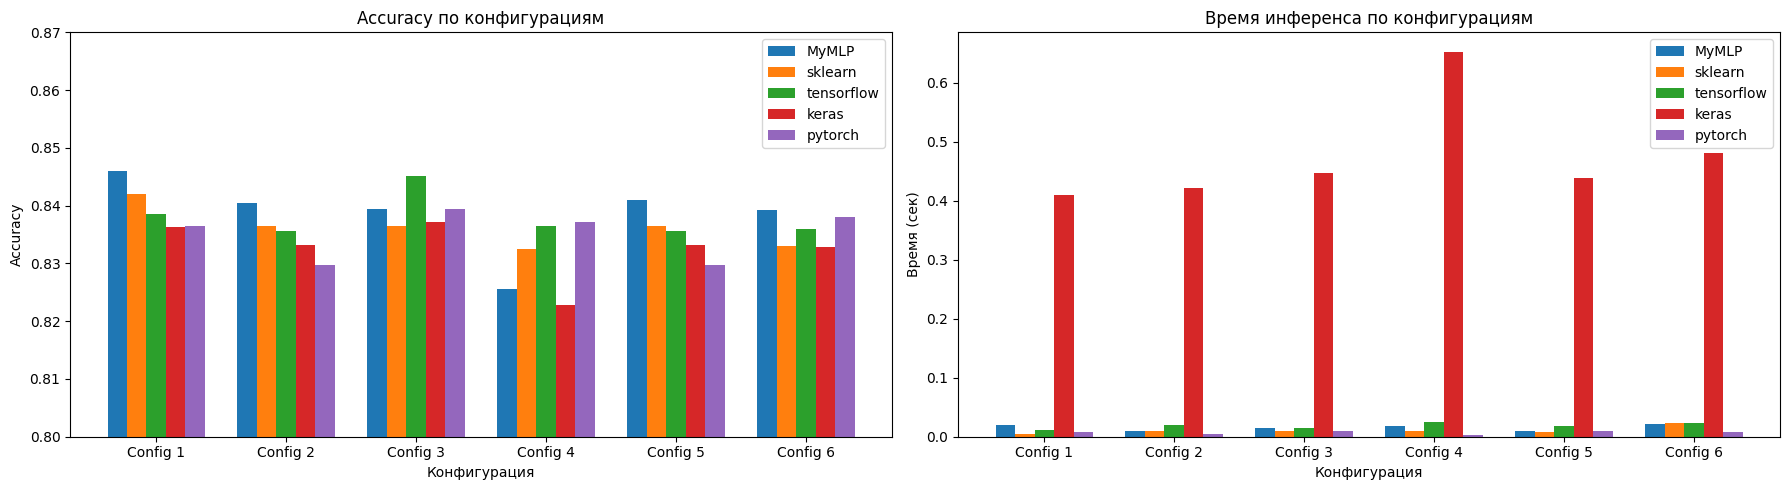

In [30]:
df_results = pd.DataFrame(results)
models = df_results["model"].unique()
configs_list = sorted(df_results["config"].unique())
x = np.arange(len(configs_list))
width = 0.15

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Accuracy
ax = axes[0]
for j, model in enumerate(models):
    vals = [df_results[(df_results["model"] == model) &
                       (df_results["config"] == c)]["accuracy"].values[0]
            for c in configs_list]
    ax.bar(x + j * width, vals, width, label=model)

ax.set_title("Accuracy по конфигурациям")
ax.set_xlabel("Конфигурация")
ax.set_ylabel("Accuracy")
ax.set_xticks(x + width * 2)
ax.set_xticklabels([f"Config {c}" for c in configs_list])
ax.legend()
ax.set_ylim(0.8, 0.87)

# Время инференса
ax = axes[1]
for j, model in enumerate(models):
    vals = [df_results[(df_results["model"] == model) &
                       (df_results["config"] == c)]["infer_time"].values[0]
            for c in configs_list]
    ax.bar(x + j * width, vals, width, label=model)

ax.set_title("Время инференса по конфигурациям")
ax.set_xlabel("Конфигурация")
ax.set_ylabel("Время (сек)")
ax.set_xticks(x + width * 2)
ax.set_xticklabels([f"Config {c}" for c in configs_list])
ax.legend()

plt.tight_layout()
plt.show()

**Вывод:** В ходе эксперимента было проведено сравнение собственной реализации многослойного перцептрона (MyMLP) с библиотечными моделями sklearn, TensorFlow, Keras и PyTorch.

Полученные результаты показывают, что качество классификации (accuracy и F1) у всех моделей находится на сопоставимом уровне (accuracy ≈ 0.83–0.85, F1 ≈ 0.61–0.67).

По времени обучения MyMLP чаще всего демонстрирует наиболее быстрые результаты, опережая модели TensorFlow, Keras и PyTorch, что связано с отсутствием накладных расходов вычислительных фреймворков. Библиотечные реализации обучаются дольше, но используют более сложные механизмы оптимизации.

По скорости инференса различия между моделями незначительны. MyMLP, PyTorch и sklearn в основном показывают лучшие результаты в сравнение с Keras, который оказывается более медленным.


### **Регрессия**

Для решения задачи регресии будет использоваться датасет [House Prices](https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques) с Kaggle, описывающий (почти) каждый аспект жилых домов в Эймсе, штат Айова для предсказания цены продажи каждого дома.

In [51]:
# Загружаем датасет
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [52]:
# Разделяем датасет
X = df.drop("SalePrice", axis=1)
y = np.log1p(df["SalePrice"]).values.reshape(-1, 1)

In [53]:
# Обрабатываем пропуски
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object"]).columns

X[num_cols] = X[num_cols].fillna(X[num_cols].median())
X[cat_cols] = X[cat_cols].fillna("Missing")

In [54]:
# One-hot encoding
X = pd.get_dummies(X, drop_first=True)

In [55]:
# Разделение данных на тренировочную и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
# Масштабируем
x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train)
X_test = x_scaler.transform(X_test)

y_scaler = StandardScaler()
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

In [57]:
configs = [
    {"layers": [64], "acts": ["relu"], "lr": 0.01},
    {"layers": [128, 64], "acts": ["relu", "relu"], "lr": 0.001},
    {"layers": [128, 64], "acts": ["relu", "relu"], "lr": 0.0005},
    {"layers": [256, 128, 64], "acts": ["relu", "relu", "relu"], "lr": 0.0005},
    {"layers": [128, 64], "acts": ["relu", "relu"],"lr": 0.001, "reg": "l2", "lambda": 0.01},
    {"layers": [128, 64], "acts": ["relu", "sigmoid"], "lr": 0.001},]

In [60]:
results = []

for i, cfg in enumerate(configs):
    set_seed(42)
    layers = cfg["layers"]
    acts = cfg["acts"]
    lr = cfg["lr"]
    reg_type = cfg.get("reg")
    reg_lambda = cfg.get("lambda", 0.0)

    print(f"\nКонфигурация {i+1}")
    print(f"Слои: {layers}")
    print(f"Активации: {acts}")
    print(f"Learning rate: {lr}")
    print(f"Регуляризация: {reg_type}, lambda={reg_lambda}")

    assert len(layers) == len(acts)

    # Архитектура
    layer_sizes = [X_train.shape[1]] + layers + [1]
    activations = acts + ["linear"]

    model = MyMLP(
        layer_sizes=layer_sizes,
        activations=activations,
        loss="mse",
        learning_rate=lr,
        reg_type=reg_type,
        reg_lambda=reg_lambda)

    # Train
    start = time.time()

    epochs = cfg.get("epochs", 400)
    batch_size = cfg.get("batch_size", 64)

    model.fit(
        X_train,
        y_train_scaled,
        epochs=epochs,
        batch_size=batch_size,
        verbose=False)

    train_time = time.time() - start
    final_loss = model.loss_history[-1]

    # Inference
    start = time.time()

    y_pred_scaled = model.predict(X_test)
    infer_time = time.time() - start

    y_pred_log = y_scaler.inverse_transform(y_pred_scaled)
    y_pred = np.expm1(y_pred_log)

    # Метрики
    mse = mean_squared_error(y_test_orig, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_orig, y_pred)
    r2 = r2_score(y_test_orig, y_pred)

    results.append({
        "model": "MyMLP",
        "config": i + 1,
        "layers": str(layers),
        "lr": lr,
        "reg": reg_type,
        "mse": mse,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "loss": final_loss,
        "train_time": train_time,
        "infer_time": infer_time})

    print(f"RMSE: {rmse:.2f}, R2: {r2:.4f}")


Конфигурация 1
Слои: [64]
Активации: ['relu']
Learning rate: 0.01
Регуляризация: None, lambda=0.0
RMSE: 31393.21, R2: 0.8715

Конфигурация 2
Слои: [128, 64]
Активации: ['relu', 'relu']
Learning rate: 0.001
Регуляризация: None, lambda=0.0
RMSE: 39902.45, R2: 0.7924

Конфигурация 3
Слои: [128, 64]
Активации: ['relu', 'relu']
Learning rate: 0.0005
Регуляризация: None, lambda=0.0
RMSE: 40380.13, R2: 0.7874

Конфигурация 4
Слои: [256, 128, 64]
Активации: ['relu', 'relu', 'relu']
Learning rate: 0.0005
Регуляризация: None, lambda=0.0
RMSE: 34604.52, R2: 0.8439

Конфигурация 5
Слои: [128, 64]
Активации: ['relu', 'relu']
Learning rate: 0.001
Регуляризация: l2, lambda=0.01
RMSE: 39833.56, R2: 0.7931

Конфигурация 6
Слои: [128, 64]
Активации: ['relu', 'sigmoid']
Learning rate: 0.001
Регуляризация: None, lambda=0.0
RMSE: 35027.35, R2: 0.8400


In [61]:
# Sklearn
sklearn_results = []

for i, cfg in enumerate(configs):
    set_seed(42)
    layers = tuple(cfg["layers"])
    lr = cfg["lr"]

    print(f"\n[sklearn] Конфигурация {i+1}")

    model = MLPRegressor(
        hidden_layer_sizes=layers,
        activation='relu',
        learning_rate_init=lr,
        max_iter=400,
        batch_size=64,
        random_state=42)

    # Train
    start = time.time()
    model.fit(X_train, y_train_scaled.ravel())
    train_time = time.time() - start

    # Inference
    start = time.time()
    y_pred_scaled = model.predict(X_test).reshape(-1, 1)
    y_pred_log = y_scaler.inverse_transform(y_pred_scaled)
    y_pred = np.expm1(y_pred_log)
    infer_time = time.time() - start

    # Метрики
    mse = mean_squared_error(y_test_orig, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_orig, y_pred)
    r2 = r2_score(y_test_orig, y_pred)

    sklearn_results.append({
        "model": "sklearn",
        "config": i + 1,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "train_time": train_time,
        "infer_time": infer_time})

    print(f"RMSE: {rmse:.2f}, R2: {r2:.4f}")


[sklearn] Конфигурация 1
RMSE: 31502.48, R2: 0.8706

[sklearn] Конфигурация 2
RMSE: 31310.48, R2: 0.8722

[sklearn] Конфигурация 3
RMSE: 33304.24, R2: 0.8554

[sklearn] Конфигурация 4
RMSE: 33104.16, R2: 0.8571

[sklearn] Конфигурация 5
RMSE: 31310.48, R2: 0.8722

[sklearn] Конфигурация 6
RMSE: 31310.48, R2: 0.8722


In [62]:
# TensorFlow
tf_results = []

for i, cfg in enumerate(configs):
    set_seed(42)

    print(f"\n[TensorFlow] Конфигурация {i+1}")

    weights_tf = []
    biases_tf = []
    prev_dim = X_train.shape[1]

    for units in cfg["layers"]:
        W = tf.Variable(tf.random.normal([prev_dim, units], stddev=0.1))
        b = tf.Variable(tf.zeros([units]))
        weights_tf.append(W)
        biases_tf.append(b)
        prev_dim = units

    W_out = tf.Variable(tf.random.normal([prev_dim, 1], stddev=0.1))
    b_out = tf.Variable(tf.zeros([1]))

    optimizer = tf.optimizers.Adam(learning_rate=cfg["lr"])

    X_tf = tf.constant(X_train, dtype=tf.float32)
    y_tf = tf.constant(y_train_scaled, dtype=tf.float32)

    dataset = tf.data.Dataset.from_tensor_slices((X_tf, y_tf))
    dataset = dataset.shuffle(buffer_size=1000).batch(64)

    def forward(X):
        A = X
        for W, b, act in zip(weights_tf, biases_tf, cfg["acts"]):
            Z = A @ W + b
            if act == "relu":
                A = tf.nn.relu(Z)
            elif act == "sigmoid":
                A = tf.nn.sigmoid(Z)
            else:
                A = Z
        return A @ W_out + b_out

    @tf.function
    def train_step(Xb, yb):
        with tf.GradientTape() as tape:
            y_pred = forward(Xb)
            loss = tf.reduce_mean(tf.square(yb - y_pred))
        all_vars = weights_tf + biases_tf + [W_out, b_out]
        grads = tape.gradient(loss, all_vars)
        optimizer.apply_gradients(zip(grads, all_vars))

    # Train
    start = time.time()
    for epoch in range(400):
        for Xb, yb in dataset:
            train_step(Xb, yb)
    train_time = time.time() - start

    # Inference
    X_test_tf = tf.constant(X_test, dtype=tf.float32)
    start = time.time()
    y_pred_scaled = forward(X_test_tf).numpy()
    infer_time = time.time() - start

    y_pred_log = y_scaler.inverse_transform(y_pred_scaled)
    y_pred = np.expm1(y_pred_log)

    # Метрики
    mse = mean_squared_error(y_test_orig, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_orig, y_pred)
    r2 = r2_score(y_test_orig, y_pred)

    tf_results.append({
        "model": "tensorflow",
        "config": i + 1,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "train_time": train_time,
        "infer_time": infer_time})

    print(f"RMSE: {rmse:.2f}, R2: {r2:.4f}")


[TensorFlow] Конфигурация 1
RMSE: 28805.68, R2: 0.8918

[TensorFlow] Конфигурация 2
RMSE: 27194.00, R2: 0.9036

[TensorFlow] Конфигурация 3
RMSE: 30482.13, R2: 0.8789

[TensorFlow] Конфигурация 4
RMSE: 27165.87, R2: 0.9038

[TensorFlow] Конфигурация 5
RMSE: 27194.00, R2: 0.9036

[TensorFlow] Конфигурация 6
RMSE: 30493.62, R2: 0.8788


In [63]:
# Keras
keras_results = []

for i, cfg in enumerate(configs):
    set_seed(42)
    print(f"\n[Keras] Конфигурация {i+1}")

    model = Sequential()

    # Первый слой
    model.add(Dense(
        cfg["layers"][0],
        activation=cfg["acts"][0],
        input_shape=(X_train.shape[1],)))

    # Скрытые слои
    for units, act in zip(cfg["layers"][1:], cfg["acts"][1:]):
        model.add(Dense(units, activation=act))

    model.add(Dense(1, activation="linear"))

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=cfg["lr"]), loss="mse")

    # Train
    start = time.time()
    model.fit(
        X_train, y_train_scaled,
        epochs=400,
        batch_size=64,
        verbose=0)

    train_time = time.time() - start

    # Inference
    start = time.time()
    y_pred_scaled = model.predict(X_test)
    infer_time = time.time() - start

    y_pred_log = y_scaler.inverse_transform(y_pred_scaled)
    y_pred = np.expm1(y_pred_log)

    # Метрики
    mse = mean_squared_error(y_test_orig, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_orig, y_pred)
    r2 = r2_score(y_test_orig, y_pred)

    keras_results.append({
        "model": "keras",
        "config": i + 1,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "train_time": train_time,
        "infer_time": infer_time})

    print(f"RMSE: {rmse:.2f}, R2: {r2:.4f}")


[Keras] Конфигурация 1


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
RMSE: 33322.27, R2: 0.8552

[Keras] Конфигурация 2


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
RMSE: 24894.35, R2: 0.9192

[Keras] Конфигурация 3


...

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
RMSE: 25153.15, R2: 0.9175

[Keras] Конфигурация 5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
RMSE: 24894.35, R2: 0.9192

[Keras] Конфигурация 6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
RMSE: 32276.75, R2: 0.8642


In [64]:
# PyTorch
class TorchMLP(nn.Module):
    def __init__(self, input_dim, layers, acts):
        super().__init__()

        modules = []
        prev_dim = input_dim

        act_map = {
            "relu": lambda: nn.ReLU(),
            "sigmoid": lambda: nn.Sigmoid(),
            "linear": lambda: nn.Identity()}

        for units, act in zip(layers, acts):
            modules.append(nn.Linear(prev_dim, units))
            modules.append(act_map[act]())
            prev_dim = units

        modules.append(nn.Linear(prev_dim, 1))
        self.net = nn.Sequential(*modules)

    def forward(self, x):
        return self.net(x)

pytorch_results = []

for i, cfg in enumerate(configs):
    set_seed(42)
    print(f"\n[PyTorch] Конфигурация {i+1}")

    model = TorchMLP(
        input_dim=X_train.shape[1],
        layers=cfg["layers"],
        acts=cfg["acts"])

    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=cfg["lr"])

    X_t = torch.tensor(X_train, dtype=torch.float32)
    y_t = torch.tensor(y_train_scaled, dtype=torch.float32)

    dataset = TensorDataset(X_t, y_t)
    loader = DataLoader(dataset, batch_size=64, shuffle=True)

    # Train
    start = time.time()
    for epoch in range(400):
        model.train()
        for Xb, yb in loader:
            optimizer.zero_grad()
            outputs = model(Xb)
            loss = criterion(outputs, yb)
            loss.backward()
            optimizer.step()
    train_time = time.time() - start

    # Inference
    X_test_t = torch.tensor(X_test, dtype=torch.float32)

    start = time.time()
    model.eval()
    with torch.no_grad():
        y_pred_scaled = model(X_test_t).cpu().numpy()
    infer_time = time.time() - start

    y_pred_log = y_scaler.inverse_transform(y_pred_scaled)
    y_pred = np.expm1(y_pred_log)

    # Метрики
    mse = mean_squared_error(y_test_orig, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_orig, y_pred)
    r2 = r2_score(y_test_orig, y_pred)

    pytorch_results.append({
        "model": "pytorch",
        "config": i + 1,
        "rmse": rmse,
        "mae": mae,
        "r2": r2,
        "train_time": train_time,
        "infer_time": infer_time})

    print(f"RMSE: {rmse:.2f}, R2: {r2:.4f}")


[PyTorch] Конфигурация 1
RMSE: 31167.29, R2: 0.8734

[PyTorch] Конфигурация 2
RMSE: 26006.50, R2: 0.9118

[PyTorch] Конфигурация 3
RMSE: 27919.07, R2: 0.8984

[PyTorch] Конфигурация 4
RMSE: 25354.23, R2: 0.9162

[PyTorch] Конфигурация 5
RMSE: 26006.50, R2: 0.9118

[PyTorch] Конфигурация 6
RMSE: 28545.43, R2: 0.8938


In [65]:
df_mymlp = pd.DataFrame(results)
df_sklearn = pd.DataFrame(sklearn_results)
df_keras = pd.DataFrame(keras_results)
df_pytorch = pd.DataFrame(pytorch_results)
df_tf = pd.DataFrame(tf_results)

for df in [df_sklearn, df_tf, df_keras, df_pytorch]:
    if "loss" not in df.columns:
        df["loss"] = np.nan

cols = ["model", "config", "rmse", "r2", "loss", "train_time", "infer_time"]

df_results = pd.concat([
    df_mymlp[cols],
    df_sklearn[cols],
    df_tf[cols],
    df_keras[cols],
    df_pytorch[cols]], ignore_index=True)

df_summary = df_results.groupby(["config", "model"]).mean(numeric_only=True)
print(df_summary)

                           rmse        r2      loss  train_time  infer_time
config model                                                               
1      MyMLP       31393.207442  0.871513  0.007357    6.289819    0.000590
       keras       33322.272942  0.855238       NaN   31.628674    0.169704
       pytorch     31167.294323  0.873356       NaN   13.040517    0.001266
       sklearn     31502.484934  0.870617       NaN    1.295381    0.001494
       tensorflow  28805.684360  0.891821       NaN   13.561202    0.007510
2      MyMLP       39902.446437  0.792420  0.036774    6.970330    0.001126
       keras       24894.350312  0.919204       NaN   37.159851    0.163041
       pytorch     26006.496417  0.911824       NaN   16.511302    0.000702
       sklearn     31310.475847  0.872190       NaN    1.754562    0.002094
       tensorflow  27194.001667  0.903588       NaN   18.055128    0.010039
3      MyMLP       40380.125381  0.787420  0.066989    9.586885    0.001188
       keras

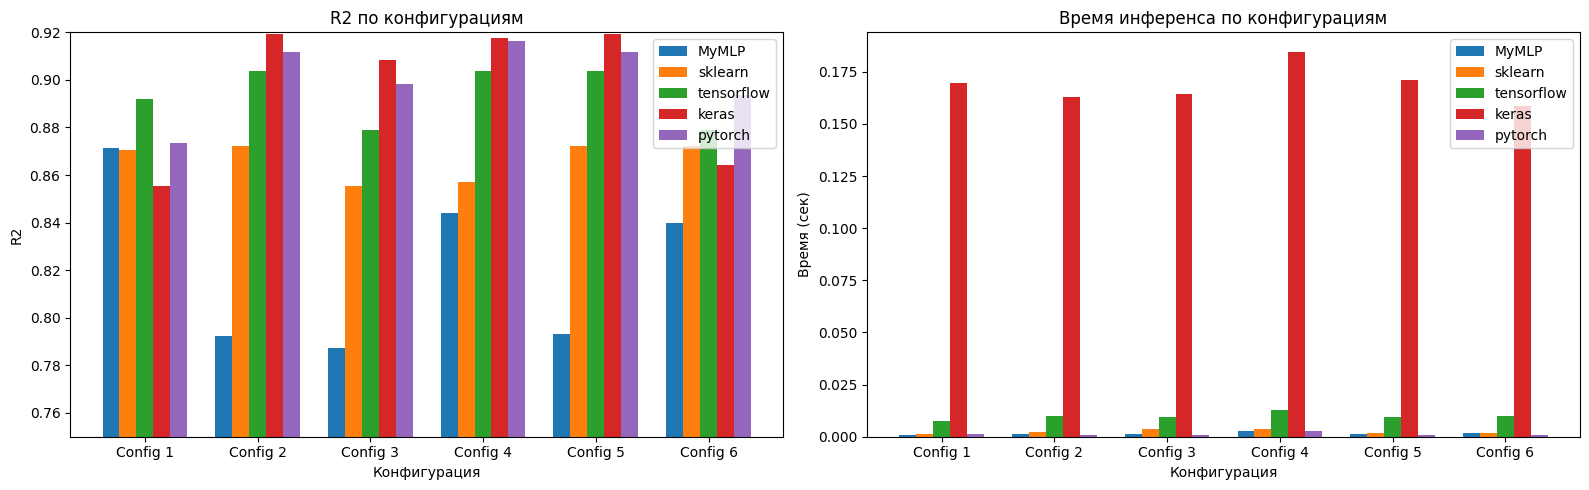

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# R2
ax = axes[0]
for j, model in enumerate(models):
    vals = [df_results[(df_results["model"] == model) &
                       (df_results["config"] == c)]["r2"].values[0]
            for c in configs_list]
    ax.bar(x + j * width, vals, width, label=model)

ax.set_title("R2 по конфигурациям")
ax.set_xlabel("Конфигурация")
ax.set_ylabel("R2")
ax.set_xticks(x + width * 2)
ax.set_xticklabels([f"Config {c}" for c in configs_list])
ax.legend()
ax.set_ylim(0.75, 0.92)

# Infer time
ax = axes[1]
for j, model in enumerate(models):
    vals = [df_results[(df_results["model"] == model) &
                       (df_results["config"] == c)]["infer_time"].values[0]
            for c in configs_list]
    ax.bar(x + j * width, vals, width, label=model)

ax.set_title("Время инференса по конфигурациям")
ax.set_xlabel("Конфигурация")
ax.set_ylabel("Время (сек)")
ax.set_xticks(x + width * 2)
ax.set_xticklabels([f"Config {c}" for c in configs_list])
ax.legend()

plt.tight_layout()
plt.show()

**Вывод:** В ходе эксперимента было проведено сравнение собственной реализации многослойного перцептрона (MyMLP) с библиотечными моделями sklearn, TensorFlow, Keras и PyTorch.

По качеству предсказания наилучшие результаты показали Keras и TensorFlow (R² ≈ 0.90–0.92), немного ниже PyTorch (R² ≈ 0.89–0.92). Sklearn демонстрирует сопоставимые результаты (R² ≈ 0.87–0.88), но при этом быстрее сходится, что связано с внутренним критерием остановки.

MyMLP показывает более низкие результаты (R² ≈ 0.79–0.87), что связано с отсутствием продвинутых механизмов оптимизации по сравнению с библиотечными реализациями Adam.

По скорости инференса все модели показывают сопоставимые результаты, за исключением Keras, который работает медленнее из-за накладных расходов фреймворка.